In [3]:
import easyocr
import numpy as np
from PIL import Image
import cv2


ocr_model = easyocr.Reader(['ch_sim','en'])
image_path = "/mnt/petrelfs/songmingyang/code/reasoning/tool-agent/tool_server/tool_workers/online_workers/test_cases/worker_tests/input_cases/subplot_0.png"
img = Image.open(image_path).convert('RGB')

result = ocr_model.readtext(np.array(img))

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [12]:
img.width

800

In [4]:
detections = []
for polygon, label, confidence in result:
    # 从四边形坐标提取 x/y 最小最大值作为 bbox
    
    x_coords = [pt[0] for pt in polygon]
    y_coords = [pt[1] for pt in polygon]
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)

    detections.append({
        "label": label,
        "confidence": confidence,
        "normalized_bbox": {
            "x_min": x_min,
            "y_min": y_min,
            "x_max": x_max,
            "y_max": y_max
        }
    })

In [2]:
result

[([[193, 1], [259, 1], [259, 17], [193, 17]], 'Australia', 0.9286681189322621),
 ([[584, 2], [651, 2], [651, 21], [584, 21]], 'Germany', 0.8875866974045028),
 ([[25, 21], [47, 21], [47, 35], [25, 35]], '0.9', 0.3303126096725464),
 ([[25, 43], [47, 43], [47, 57], [25, 57]], '08', 0.996163592600907),
 ([[417, 43], [439, 43], [439, 57], [417, 57]], '07', 0.9840477696928358),
 ([[6, 50], [23, 50], [23, 109], [6, 109]], ')', 0.00023014324115475885),
 ([[25, 67], [47, 67], [47, 81], [25, 81]], '0.7', 0.5138545989754909),
 ([[417, 73], [439, 73], [439, 87], [417, 87]], '0.6', 0.8308912325817863),
 ([[25, 89], [47, 89], [47, 105], [25, 105]], '06', 0.9995456872055692),
 ([[417, 103], [439, 103], [439, 119], [417, 119]], '0,5', 0.4116230401072355),
 ([[25, 113], [47, 113], [47, 129], [25, 129]], '0,5', 0.4738872293653226),
 ([[199, 145], [251, 145], [251, 161], [199, 161]],
  'Poland',
  0.9979355051409668),
 ([[591, 145], [645, 145], [645, 161], [591, 161]],
  'Taiwan',
  0.7223141732680322),


In [5]:
def draw_bbox(img, x_min, y_min, x_max, y_max, color=(0, 255, 0), thickness=2):
    """
    在图像上画出边界框，支持归一化和像素坐标，自动判断。

    Args:
        img (np.ndarray): 输入图像，shape=(H, W, C)
        x_min, y_min, x_max, y_max (float): 边界框的坐标
        color (tuple): 画框的颜色，默认绿色
        thickness (int): 线宽，默认 2

    Returns:
        np.ndarray: 画好框的图像
    """
    h, w = img.shape[:2]

    # 自动判断是否为归一化坐标
    if 0 <= x_min <= 1 and 0 <= y_min <= 1 and 0 <= x_max <= 1 and 0 <= y_max <= 1:
        x_min = int(x_min * w)
        x_max = int(x_max * w)
        y_min = int(y_min * h)
        y_max = int(y_max * h)
    else:
        x_min = int(x_min)
        x_max = int(x_max)
        y_min = int(y_min)
        y_max = int(y_max)

    img_with_box = img.copy()
    cv2.rectangle(img_with_box, (x_min, y_min), (x_max, y_max), color, thickness)

    return img_with_box

In [6]:
a = draw_bbox(np.array(img), **detections[0]['normalized_bbox'])

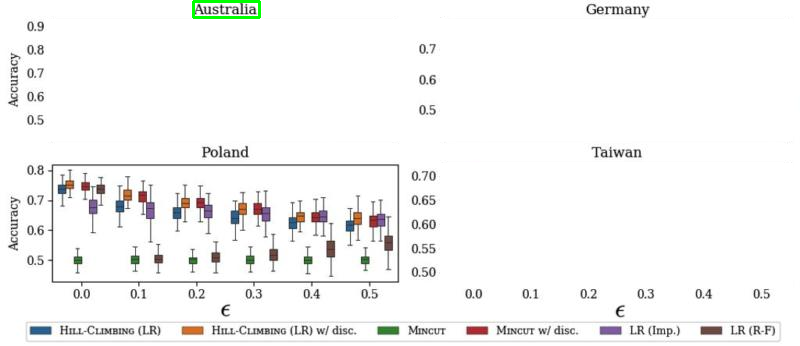

In [8]:
a = Image.fromarray(a)
a
